

---


## ✍️ Author  

This notebook was created by **Mohamed Roshdy**.  
last edit 3/9/2025

📫 Feel free to connect with me:  
- [GitHub](https://github.com/TheRealRoshdy)  
- [LinkedIn](https://www.linkedin.com/in/mohamed-roshdy2001/)  
- [Email](mailto:roshdy13122001@gmail.com)  


---



# Student performance predection using linear regression
## 📊 Dataset

This project uses the **Student Performance Factors** dataset.  
Dataset source: [Kaggle – Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)
Credits: *Lai Nguyễn* (original uploader on Kaggle)

---




In [144]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/Student_Performance_Factors.zip /content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [145]:
!unzip -q /content/Student_Performance_Factors.zip -d /content/dataset

replace /content/dataset/StudentPerformanceFactors.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Simple linear regression
using only one feature, Hours_Studied, to train the model.

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [147]:
df = pd.read_csv("/content/dataset/StudentPerformanceFactors.csv")

In [148]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [150]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [151]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


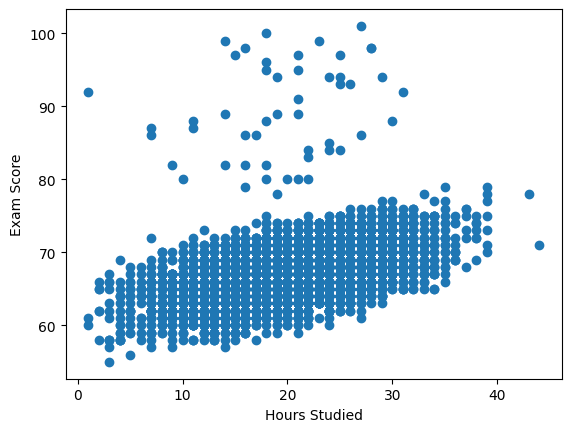

In [152]:
# Scatter plot showing the relationship between Hours Studied and Exam Score, differentiated by Gender
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()


Keep only Hours_Studied and Exam_Score columns.



---


As observed, the relationsip between the feature Hours_Studied and Exam_Score
is linear. Therefore, fitting a linear curve will be the best choice.

In [153]:
df = df[['Hours_Studied', 'Exam_Score']]

In [154]:
df.head()

,Hours_Studied,Exam_Score
0,23,67
1,19,61
2,24,74
3,29,71
4,19,70


Check if either column has missing entries.

In [155]:
df.isnull().sum()

,0
Hours_Studied,0
Exam_Score,0


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours_Studied  6607 non-null   int64
 1   Exam_Score     6607 non-null   int64
dtypes: int64(2)
memory usage: 103.4 KB


select labels (y) and featuers (X) and split the data to train validation and test.

In [157]:
train, valid, test= np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [158]:
# Training data
X_train = train[['Hours_Studied']]   # 2D
y_train = train['Exam_Score']        # 1D

# Validation data
X_val = valid[['Hours_Studied']]
y_val = valid['Exam_Score']

# Test data
X_test = test[['Hours_Studied']]
y_test = test['Exam_Score']

load the model

In [159]:
model = LinearRegression()
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)

print("Validation MSE:", mean_squared_error(y_val, y_val_pred))
print("Validation R²:", r2_score(y_val, y_val_pred))

Validation MSE: 11.333464432658793
Validation R²: 0.22544591927319835


In [160]:
y_test_pred = model.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))


Test MSE: 11.84007953842516
Test R²: 0.19115068669937607


In [161]:
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

Intercept (b0): 61.472412089435196
Slope (b1): 0.2897946733312162


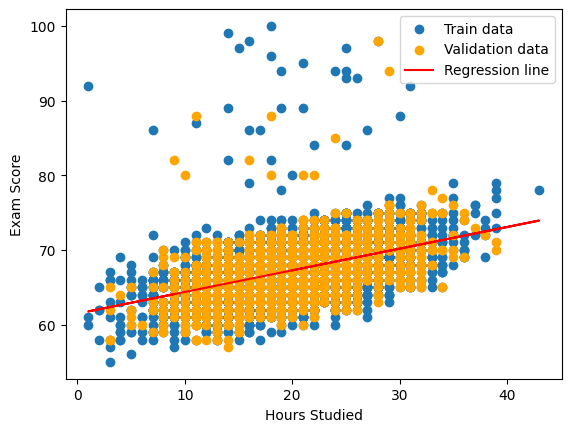

In [162]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, label="Train data")
plt.scatter(X_val, y_val, label="Validation data", color="orange")
plt.plot(X_train, model.predict(X_train), color="red", label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()


# Multi-Linear reggresion model


---
## 📌 Why Use Multiple Linear Regression Instead of a Single Feature?

When predicting student performance (or any outcome), relying on **only one feature** (Simple Linear Regression) can miss important relationships.  

- 🎯 **More Information = Better Predictions**  
  Student performance is influenced by many factors (study time, parental support, attendance, etc.). Using multiple features helps the model capture these combined effects.  

- 📊 **Reduces Bias**  
  A single feature may lead to an oversimplified model, ignoring other key variables. Multiple features give a more realistic representation of the problem.  

- 🔄 **Captures Interactions**  
  Some factors work together (e.g., study time *and* sleep quality). Multi Linear Regression can capture these combined influences better than a single-feature model.  

- 📈 **Improved Accuracy**  
  More relevant features usually mean higher **R² (coefficient of determination)** and lower error (MSE/MAE), because the model explains more variance in the data.  

👉 In short: **Multiple Linear Regression is more powerful** because it considers several predictors at once, leading to better accuracy compared to using only one variable.  



In [163]:
df = pd.read_csv("/content/dataset/StudentPerformanceFactors.csv")

In [164]:
# Show datatypes
print("Column Data Types:\n")
print(df.dtypes)

print("\nUnique values for object (string) columns:\n")
for col in df.select_dtypes(include=['object']).columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print("-" * 50)

Column Data Types:

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

Unique values for object (string) columns:

Column: Parental_Involvement
['Low' 'Medium' 'High']
--------------------------------------------------
Column: Access_to_Resources
['High' 'Medium' 'Low']
-------------------------

## 📌Encoding  

Most machine learning models can only work with **numerical data**.  
This means any **categorical features** (like gender, color, city, etc.) must be **encoded** before training.  

- 🔢 **Label Encoding** assigns each category an integer value.  
- 🔲 **One-Hot Encoding** creates binary columns for categories (0/1).  

✅ Encoding is a **must** step — without it, models cannot interpret text-based or categorical features properly.  


In [165]:
def auto_encode_dataframe(df: pd.DataFrame):
    df_encoded = df.copy()
    le = LabelEncoder()

    for col in df.select_dtypes(include=['object']).columns:
        unique_vals = df_encoded[col].dropna().unique()
        col_idx = df_encoded.columns.get_loc(col)  # get original position

        # Case 1: Binary categorical → One-Hot Encoding (1 column only)
        if len(unique_vals) == 2:
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            df_encoded.drop(col, axis=1, inplace=True)
            for i, new_col in enumerate(dummies.columns):
                df_encoded.insert(col_idx + i, new_col, dummies[new_col])

        # Case 2: More than 2 categories → Label Encoding
        else:
            df_encoded[col] = df_encoded[col].astype(str)
            df_encoded[col] = le.fit_transform(df_encoded[col])

    return df_encoded

df_encoded = auto_encode_dataframe(df)
df_encoded.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities_Yes,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access_Yes,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type_Public,Peer_Influence,Physical_Activity,Learning_Disabilities_Yes,Parental_Education_Level,Distance_from_Home,Gender_Male,Exam_Score
0,23,84,1,0,False,7,73,1,True,0,1,2,True,2,3,False,1,2,True,67
1,19,64,1,2,False,8,59,1,True,2,2,2,True,0,4,False,0,1,False,61
2,24,98,2,2,True,7,91,2,True,2,2,2,True,1,4,False,2,2,True,74
3,29,89,1,2,True,8,98,2,True,1,2,2,True,0,4,False,1,1,True,71
4,19,92,2,2,True,6,65,2,True,3,2,0,True,1,4,False,0,2,False,70


## 📌 About the `auto_encode_dataframe` Function

The `auto_encode_dataframe` function is a custom preprocessing tool that automatically encodes categorical columns in a DataFrame, making the dataset ready for machine learning.  

### 🔎 How it works:
1. Makes a copy of the input DataFrame.  
2. Loops through all **categorical (object-type)** columns.  
3. For each column:  
   - **Binary categories (2 unique values):**  
     → Applies **One-Hot Encoding** (creates 1 new binary column, dropping the first to avoid redundancy).  
     *Example:* `"Male/Female"` → `Gender_Male` (0 or 1).  
   - **More than 2 categories:**  
     → Applies **Label Encoding** (converts categories into integers).  
     *Example:* `"Red, Green, Blue"` → `0, 1, 2`.  
4. Preserves the original column order.  
5. Returns the fully encoded DataFrame (numeric-only).  

### ✅ Why it’s useful:
- Simplifies preprocessing by handling binary and multi-class features automatically.  
- Ensures machine learning algorithms can work with categorical data.  
- Keeps binary encoding compact (only 1 column).  

⚠️ **Note:** Label Encoding is fine for tree-based models (Random Forest, XGBoost, etc.), but for linear models or distance-based models, One-Hot Encoding is usually preferred for multi-class features.  




---


## 📊 Plotting Features vs. Label  

Before training a regression model, it is useful to **visualize each feature against the target label**.  

- 📈 If the relationship looks **linear (points roughly follow a line/trend)**, then the feature is a good candidate for **Linear Regression**.  
- 🔀 If the relationship is **non-linear or scattered**, linear regression may not capture it well, and other models (polynomial regression, tree-based methods, etc.) may perform better.  
- 🎯 These plots help us **understand feature importance** and decide whether a single feature is enough or if multiple features are needed for better accuracy.  

👉 In short: plotting each feature against the label helps us **check linearity** and guides us in choosing the right regression approach.  


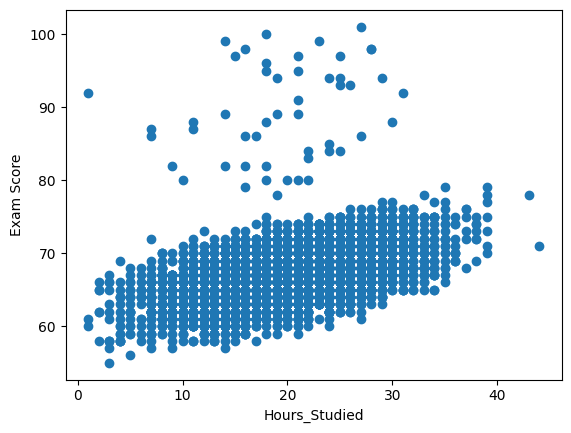

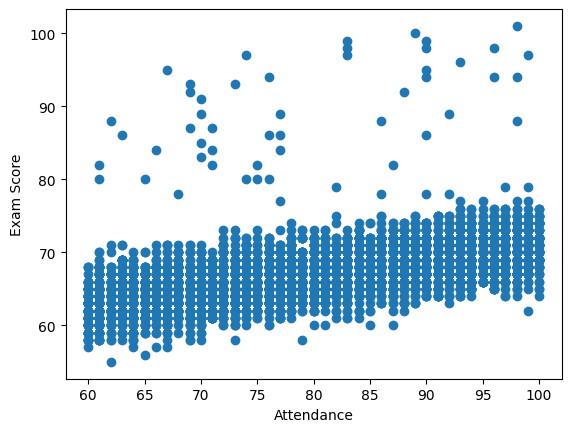

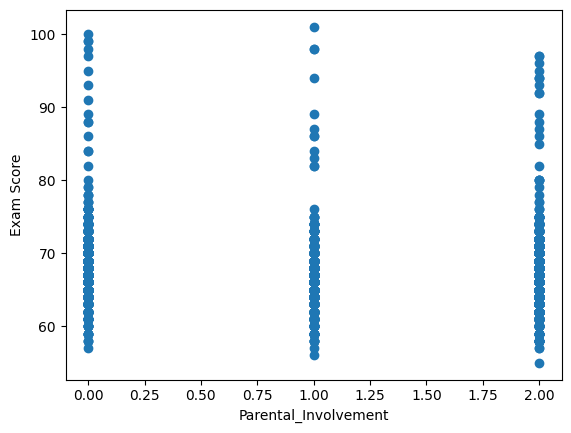

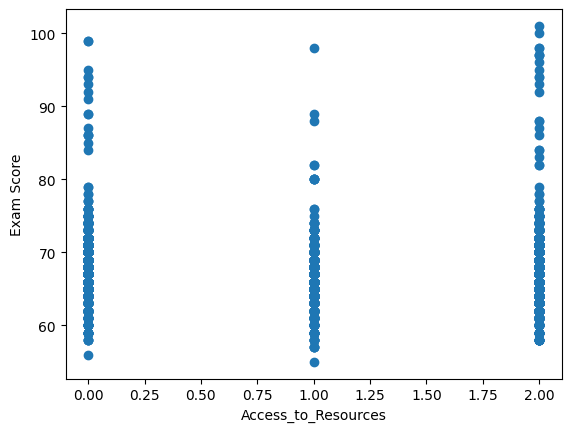

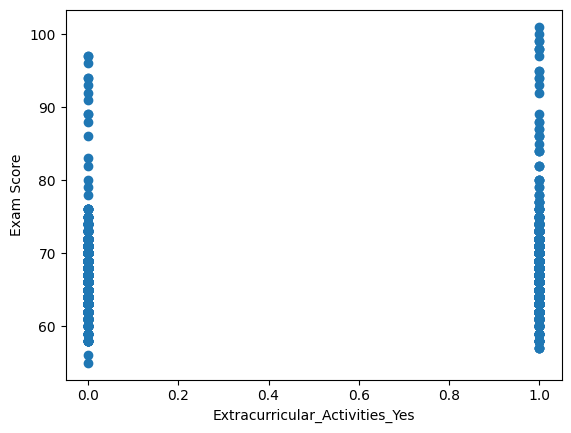

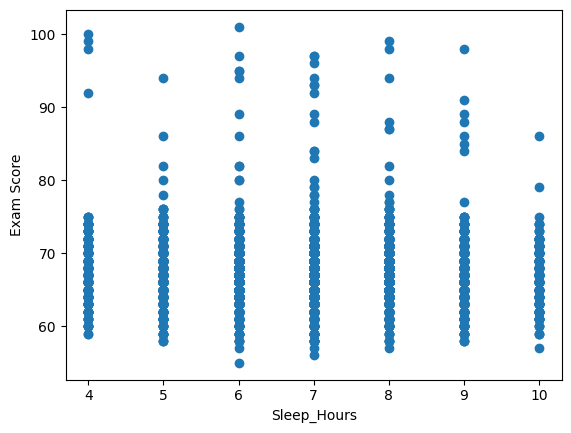

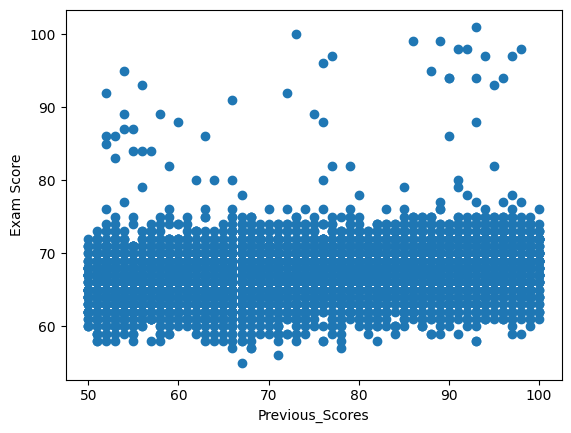

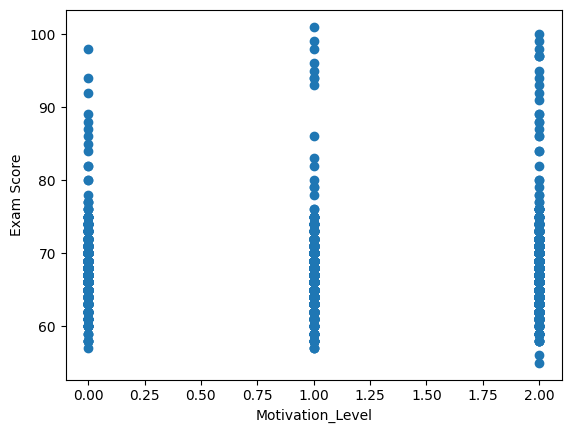

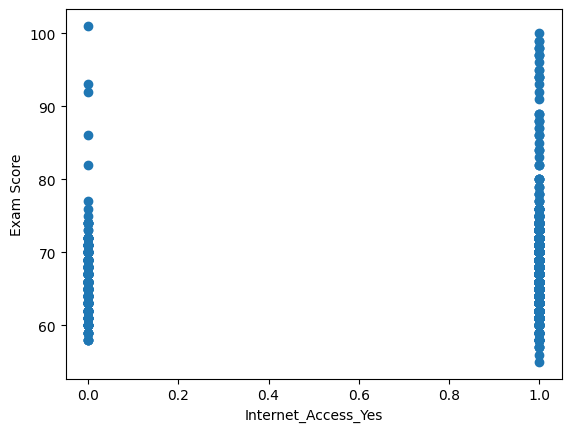

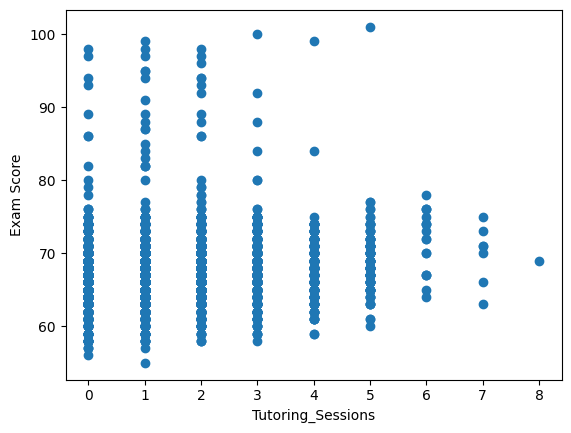

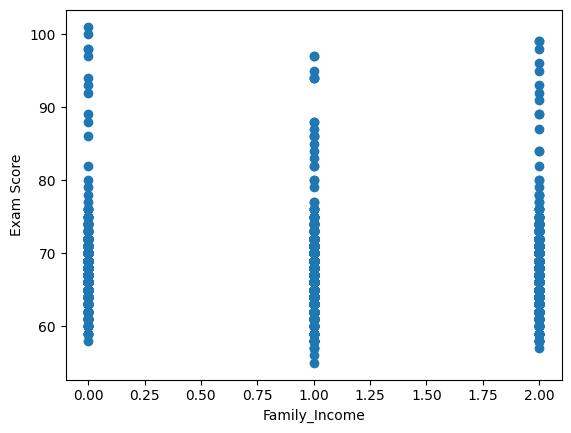

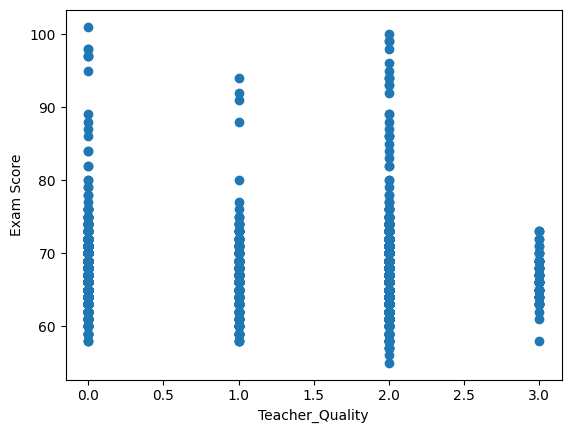

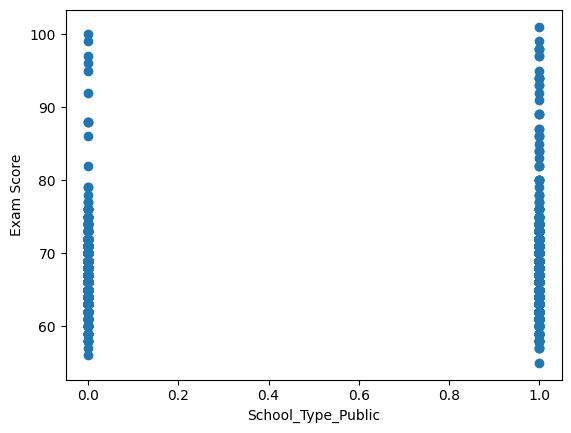

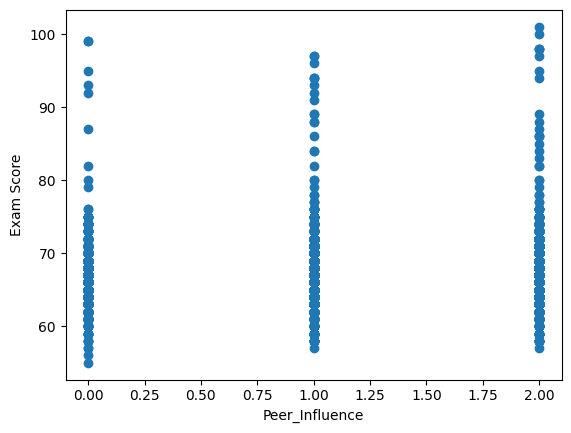

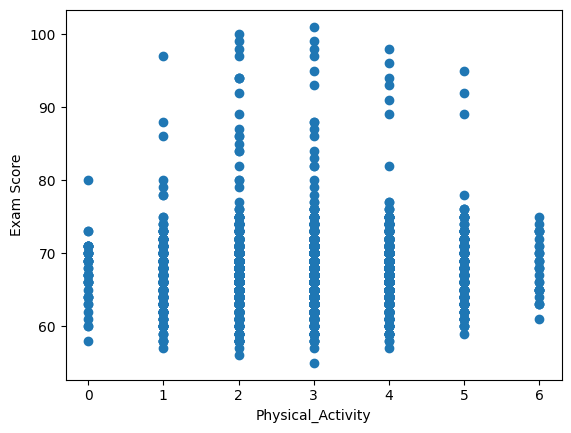

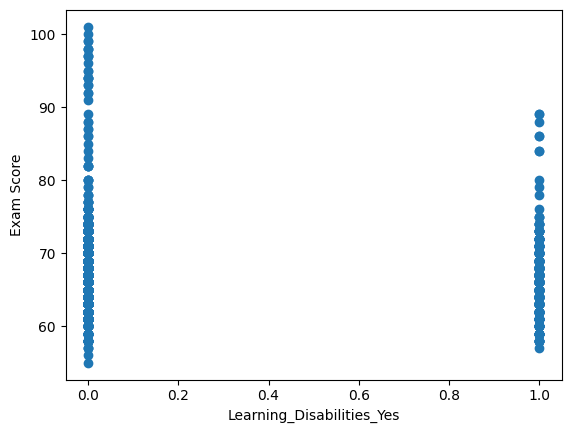

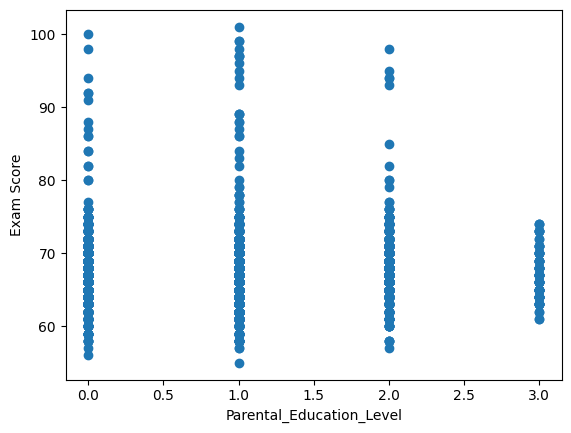

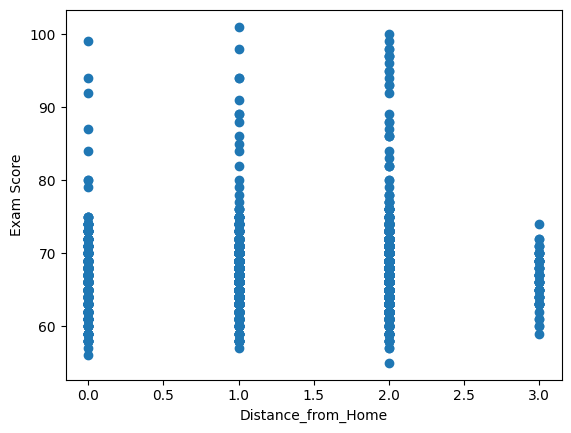

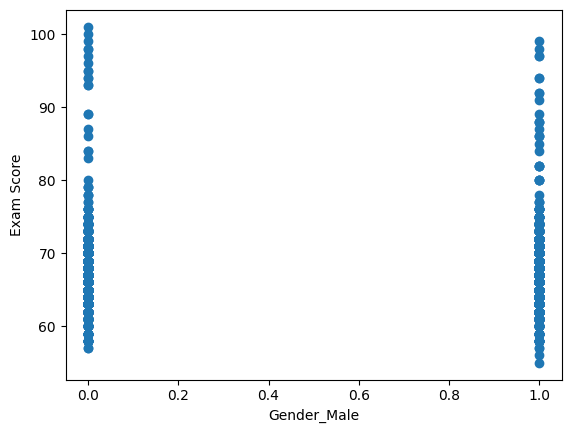

In [166]:
for label in df_encoded.columns[:-1]:
  plt.scatter(df_encoded[label], df_encoded['Exam_Score'])
  plt.xlabel(label)
  plt.ylabel("Exam Score")
  plt.show()

In [167]:

# Features = all columns except Exam_Score
X_multi = df_encoded.drop("Exam_Score", axis=1)

# Target = Exam_Score
y_multi = df_encoded["Exam_Score"]

X_multi.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities_Yes,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access_Yes,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type_Public,Peer_Influence,Physical_Activity,Learning_Disabilities_Yes,Parental_Education_Level,Distance_from_Home,Gender_Male
0,23,84,1,0,False,7,73,1,True,0,1,2,True,2,3,False,1,2,True
1,19,64,1,2,False,8,59,1,True,2,2,2,True,0,4,False,0,1,False
2,24,98,2,2,True,7,91,2,True,2,2,2,True,1,4,False,2,2,True
3,29,89,1,2,True,8,98,2,True,1,2,2,True,0,4,False,1,1,True
4,19,92,2,2,True,6,65,2,True,3,2,0,True,1,4,False,0,2,False


In [168]:
from sklearn.model_selection import train_test_split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [169]:
multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

print("Intercept:", multi_model.intercept_)

# Show feature coefficients
coef_df = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": multi_model.coef_
})
coef_df.sort_values(by="Coefficient", ascending=False)

Intercept: 40.146557149357434


,Feature,Coefficient
8,Internet_Access_Yes,0.968491
4,Extracurricular_Activities_Yes,0.567475
13,Peer_Influence,0.534574
9,Tutoring_Sessions,0.502450
17,Distance_from_Home,0.442246
0,Hours_Studied,0.288644
1,Attendance,0.197930
14,Physical_Activity,0.174030
16,Parental_Education_Level,0.153472
6,Previous_Scores,0.048247


Evaluation and test

In [170]:
#test the model
y_multi_pred = multi_model.predict(X_test_multi)

# Compare actual vs predicted scores
comparison_multi = pd.DataFrame({"Actual": y_test_multi, "Predicted": y_multi_pred})
comparison_multi.head()

,Actual,Predicted
743,65,65.200832
5551,65,67.444901
3442,71,69.784143
6571,64,67.295628
4204,66,66.746602


In [171]:
#evaluate the model
mae_multi = mean_absolute_error(y_test_multi, y_multi_pred)
mse_multi = mean_squared_error(y_test_multi, y_multi_pred)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_multi, y_multi_pred)

print("Multiple Linear Regression Performance:")
print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R² Score:", r2_multi)

Multiple Linear Regression Performance:
MAE: 1.0156733842910806
MSE: 4.401387320454959
RMSE: 2.097948359816075
R² Score: 0.688619401927732


# Polynomial regression

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Use only StudyHours
X_poly = df[["Hours_Studied"]]
y_poly = df["Exam_Score"]

# Split data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

In [15]:
# Create Polynomial Regression model (degree=2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train_poly, y_train_poly)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [16]:
# test the model
y_poly_pred = poly_model.predict(X_test_poly)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


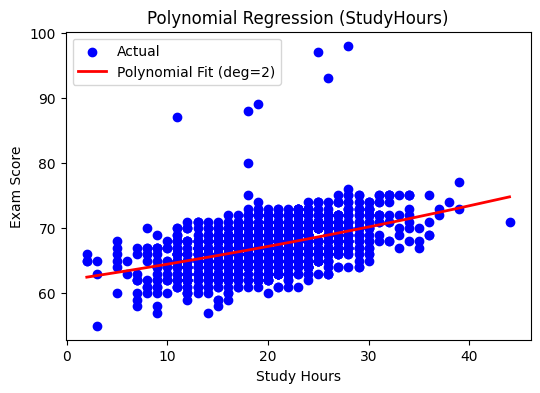

In [17]:
# Sort values for smooth curve
X_sorted = np.sort(X_test_poly, axis=0)
y_sorted = poly_model.predict(X_sorted)

plt.figure(figsize=(6,4))
plt.scatter(X_test_poly, y_test_poly, color="blue", label="Actual")
plt.plot(X_sorted, y_sorted, color="red", linewidth=2, label="Polynomial Fit (deg=2)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Polynomial Regression (StudyHours)")
plt.legend()
plt.show()

In [18]:
#evaluating the model
poly_mae = mean_absolute_error(y_test_poly, y_poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test_poly, y_poly_pred))
poly_r2 = r2_score(y_test_poly, y_poly_pred)

print("Polynomial Regression (StudyHours, degree=2)")
print("MAE:", poly_mae)
print("RMSE:", poly_rmse)
print("R²:", poly_r2)

Polynomial Regression (StudyHours, degree=2)
MAE: 2.4447795821288105
RMSE: 3.2931729586684346
R²: 0.23276034442853466


# Multiple polynomial regression

In [19]:
# Features = all except Exam_Score
X_poly_multi = df.drop("Exam_Score", axis=1)
y_poly_multi = df["Exam_Score"]

# Encode categorical features
X_poly_multi = pd.get_dummies(X_poly_multi, drop_first=True)

# Split dataset
X_train_poly_multi, X_test_poly_multi, y_train_poly_multi, y_test_poly_multi = train_test_split(X_poly_multi, y_poly_multi, test_size=0.2, random_state=42)

In [20]:
# Polynomial regression (degree=2, with multiple features)
poly_multi_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

In [21]:
# Train model
poly_multi_model.fit(X_train_poly_multi, y_train_poly_multi)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [22]:
# model testing
y_poly_multi_pred = poly_multi_model.predict(X_test_poly_multi)

In [23]:
#model evaluation
poly_multi_mae = mean_absolute_error(y_test_poly_multi, y_poly_multi_pred)
poly_multi_rmse = np.sqrt(mean_squared_error(y_test_poly_multi, y_poly_multi_pred))
poly_multi_r2 = r2_score(y_test_poly_multi, y_poly_multi_pred)

print("Polynomial Regression (Multiple Features, degree=2)")
print("MAE:", poly_multi_mae)
print("RMSE:", poly_multi_rmse)
print("R²:", poly_multi_r2)

Polynomial Regression (Multiple Features, degree=2)
MAE: 2.4447795821288105
RMSE: 3.2931729586684346
R²: 0.23276034442853466


In [141]:
display(comparison_df)

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression (Hours Studied),NaN,6.692099,2.586909,0.616391
1,Multi-Linear Regression (All Features),0.00000,0.000000,0.000000,1.000000
2,"Polynomial Regression (Hours Studied, degree=2)",2.44478,10.844988,3.293173,0.232760
3,"Polynomial Regression (Multiple Features, degr...",2.44478,10.844988,3.293173,0.232760


In [172]:
comparison_data = {
    "Model": ["Simple Linear Regression (Hours Studied)", "Multi-Linear Regression (All Features)", "Polynomial Regression (Hours Studied, degree=2)", "Polynomial Regression (Multiple Features, degree=2)"],
    "MAE": [mean_absolute_error(y_test, model.predict(X_test)), mean_absolute_error(y_test_multi, y_multi_pred), poly_mae, poly_multi_mae],
    "MSE": [mean_squared_error(y_test, model.predict(X_test)), mean_squared_error(y_test_multi, y_multi_pred), mean_squared_error(y_test_poly, y_poly_pred), mean_squared_error(y_test_poly_multi, y_poly_multi_pred)],
    "RMSE": [root_mean_squared_error(y_test, model.predict(X_test)), root_mean_squared_error(y_test_multi, y_multi_pred), poly_rmse, poly_multi_rmse],
    "R²": [r2_score(y_test, model.predict(X_test)), r2_score(y_test_multi, y_multi_pred), poly_r2, poly_multi_r2]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression (Hours Studied),2.468628,11.840080,3.440942,0.191151
1,Multi-Linear Regression (All Features),1.015673,4.401387,2.097948,0.688619
2,"Polynomial Regression (Hours Studied, degree=2)",2.444780,10.844988,3.293173,0.232760
3,"Polynomial Regression (Multiple Features, degr...",2.444780,10.844988,3.293173,0.232760


## 📊 Model Comparison & Conclusions  

From the evaluation metrics, we can see:  

- **Simple Linear Regression (Hours Studied only):**  
  - MAE = 2.46, MSE = 11.84, R² = 0.19  
  - Very low R² → this single feature explains only ~19% of the variance.  

- **Multi-Linear Regression (All Features):**  
  - MAE = 1.01, MSE = 4.40, R² = 0.69  
  - Significant improvement → using all features explains ~69% of the variance, showing that multiple factors influence performance.  

- **Polynomial Regression (Hours Studied, degree=2):**  
  - MAE = 2.44, MSE = 10.84, R² = 0.23  
  - Slight improvement over simple linear regression, but still weak → one feature alone is not enough.  

- **Polynomial Regression (Multiple Features, degree=2):**  
  - Same metrics as single-feature polynomial (MAE = 2.44, R² = 0.23)  
  - No noticeable gain → polynomial terms did not help much in this dataset.  

### ✅ Conclusion:
- **Multi-Linear Regression with all features is the best-performing model** with the lowest error and highest R² score (0.69).  
- Single-feature models (linear or polynomial) are insufficient because student performance depends on **multiple factors, not just hours studied**.  
- Polynomial terms did not provide extra benefit here, meaning the relationships are mostly **linear and additive** rather than strongly non-linear.  
